<a href="https://colab.research.google.com/github/lovnishverma/Python-Getting-Started/blob/main/pyspark_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Beginner Friendly PySpark Notebook
## Big Data Practical

This notebook teaches:
- What is PySpark
- How Spark works
- Loading CSV files
- Filtering data
- GroupBy operations
- Threat detection
- Basic visualization

Designed for beginners and classroom demonstrations.



# Step 1: Install PySpark

Run this only if PySpark is not installed.


In [1]:
# Uncomment if needed

# !pip install pyspark
# !pip install pandas
# !pip install matplotlib


# Step 2: Start Spark Session

SparkSession is the entry point to Apache Spark.


In [2]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("BeginnerPySpark") \
    .getOrCreate()

print("Spark Started Successfully")

Spark Started Successfully


# Step 3: Create Sample Cybercrime Dataset

We will create a fake dataset for learning.


In [3]:
import pandas as pd

data = {
    "ip_address": [
        "192.168.1.1",
        "192.168.1.2",
        "192.168.1.1",
        "10.0.0.5",
        "172.16.0.9"
    ],
    "url_accessed": [
        "/login",
        "/payment",
        "/admin",
        "/login",
        "/upi-transfer"
    ],
    "response_code": [
        200,
        403,
        403,
        200,
        500
    ],
    "threat_flag": [
        0,
        1,
        1,
        0,
        1
    ]
}

df = pd.DataFrame(data)

df.to_csv("cyber_logs.csv", index=False)

df

,ip_address,url_accessed,response_code,threat_flag
0,192.168.1.1,/login,200,0
1,192.168.1.2,/payment,403,1
2,192.168.1.1,/admin,403,1
3,10.0.0.5,/login,200,0
4,172.16.0.9,/upi-transfer,500,1



# Step 4: Load CSV into Spark


In [4]:
spark_df = spark.read.csv(
    "cyber_logs.csv",
    header=True,
    inferSchema=True
)

spark_df.show()

+-----------+-------------+-------------+-----------+
| ip_address| url_accessed|response_code|threat_flag|
+-----------+-------------+-------------+-----------+
|192.168.1.1|       /login|          200|          0|
|192.168.1.2|     /payment|          403|          1|
|192.168.1.1|       /admin|          403|          1|
|   10.0.0.5|       /login|          200|          0|
| 172.16.0.9|/upi-transfer|          500|          1|
+-----------+-------------+-------------+-----------+




# Step 5: Understand the Schema

Schema tells Spark about:
- column names
- data types


In [5]:
spark_df.printSchema()

root
 |-- ip_address: string (nullable = true)
 |-- url_accessed: string (nullable = true)
 |-- response_code: integer (nullable = true)
 |-- threat_flag: integer (nullable = true)




# Step 6: Count Total Records


In [6]:
total = spark_df.count()

print("Total Records:", total)

Total Records: 5



# Step 7: Filter Threat Records

We only want suspicious traffic.


In [7]:
threats = spark_df.filter(
    spark_df.threat_flag == 1
)

threats.show()

+-----------+-------------+-------------+-----------+
| ip_address| url_accessed|response_code|threat_flag|
+-----------+-------------+-------------+-----------+
|192.168.1.2|     /payment|          403|          1|
|192.168.1.1|       /admin|          403|          1|
| 172.16.0.9|/upi-transfer|          500|          1|
+-----------+-------------+-------------+-----------+




# Step 8: Find Top Suspicious IPs


In [8]:
from pyspark.sql.functions import desc

top_ips = threats.groupBy("ip_address") \
    .count() \
    .orderBy(desc("count"))

top_ips.show()

+-----------+-----+
| ip_address|count|
+-----------+-----+
|192.168.1.2|    1|
|192.168.1.1|    1|
| 172.16.0.9|    1|
+-----------+-----+




# Step 9: Count Response Codes

This helps detect:
- login failures
- server issues
- brute-force attacks


In [9]:
response_analysis = spark_df.groupBy(
    "response_code"
).count()

response_analysis.show()

+-------------+-----+
|response_code|count|
+-------------+-----+
|          500|    1|
|          403|    2|
|          200|    2|
+-------------+-----+




# Step 10: Convert Spark DataFrame to Pandas

Useful for plotting charts.


In [10]:
pandas_df = response_analysis.toPandas()

pandas_df

,response_code,count
0,500,1
1,403,2
2,200,2



# Step 11: Visualization


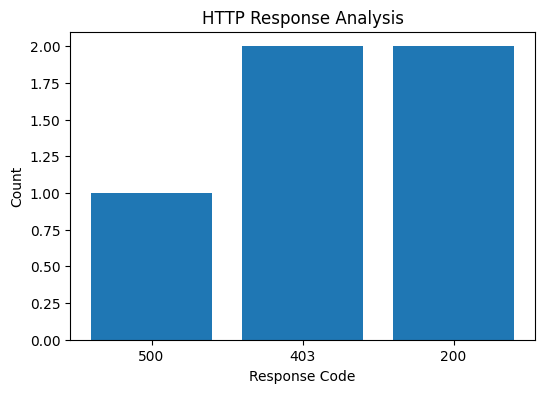

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(
    pandas_df["response_code"].astype(str),
    pandas_df["count"]
)

plt.xlabel("Response Code")
plt.ylabel("Count")
plt.title("HTTP Response Analysis")

plt.show()


# Step 12: SQL Queries in Spark

Spark also supports SQL.


In [12]:
spark_df.createOrReplaceTempView("logs")

result = spark.sql("""
SELECT ip_address, COUNT(*) AS total
FROM logs
GROUP BY ip_address
ORDER BY total DESC
""")

result.show()

+-----------+-----+
| ip_address|total|
+-----------+-----+
|192.168.1.1|    2|
|192.168.1.2|    1|
|   10.0.0.5|    1|
| 172.16.0.9|    1|
+-----------+-----+




# Step 13: Stop Spark Session


In [13]:
spark.stop()

print("Spark Session Stopped")

Spark Session Stopped



# Exercises for Students

## Exercise 1
Find all IPs generating 403 errors.

## Exercise 2
Find URLs with maximum traffic.

## Exercise 3
Find all suspicious requests.

## Exercise 4
Create a larger dataset.

## Exercise 5
Visualize threat traffic.

---

# What Students Learned

- Spark basics
- DataFrames
- Filtering
- GroupBy
- SQL in Spark
- Basic analytics
- Visualization
